In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/My drive/financial_fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,origin_location,dest_location,date
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,Chennai,Goa,2020-01-01 01:00:00
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,Kolkata,Chennai,2020-01-01 01:00:00
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,Singapore,London,2020-01-01 01:00:00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,Delhi,Jammu,2020-01-01 01:00:00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,Kolkata,Chennai,2020-01-01 01:00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   type             object 
 2   amount           float64
 3   nameOrig         object 
 4   oldbalanceOrg    float64
 5   newbalanceOrig   float64
 6   nameDest         object 
 7   oldbalanceDest   float64
 8   newbalanceDest   float64
 9   isFraud          int64  
 10  isFlaggedFraud   int64  
 11  origin_location  object 
 12  dest_location    object 
 13  date             object 
dtypes: float64(5), int64(3), object(6)
memory usage: 679.6+ MB


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


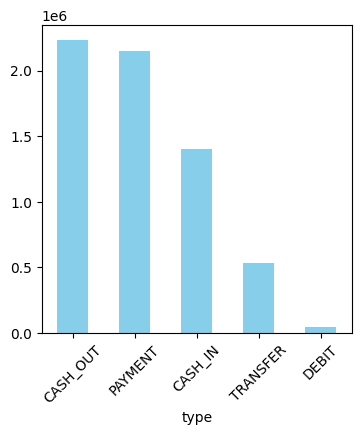

In [ ]:

val_count = df["type"].value_counts()
fig = plt.figure(figsize=(4,4))
val_count.plot(kind="bar", color="skyblue")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
len(df[ ( df["isFraud"] == 1 ) & ( df["isFlaggedFraud"]==1) ])

16

One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc = ohe.fit_transform(df[["type"]])
enc_df = pd.DataFrame(enc, columns= ohe.get_feature_names_out(["type"]))
df_encoded = pd.concat([df, enc_df], axis=1)

In [ ]:
df_encoded = df_encoded.sample(
    n=100000,
    random_state=42
)

### Transforming data to numeric and assigning integers to strings

In [ ]:
num_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
       "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud",
        "type_CASH_IN", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT",
       "type_TRANSFER"]

cat_cols = ["nameOrig", "nameDest", "origin_location", "dest_location"]

df_encoded[num_cols] = df_encoded[num_cols].apply(pd.to_numeric, errors="coerce")

for col in cat_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

Dropping type, date  features as date is derived from step

In [ ]:
df_encoded = df_encoded.drop(["type","date"], axis=1)

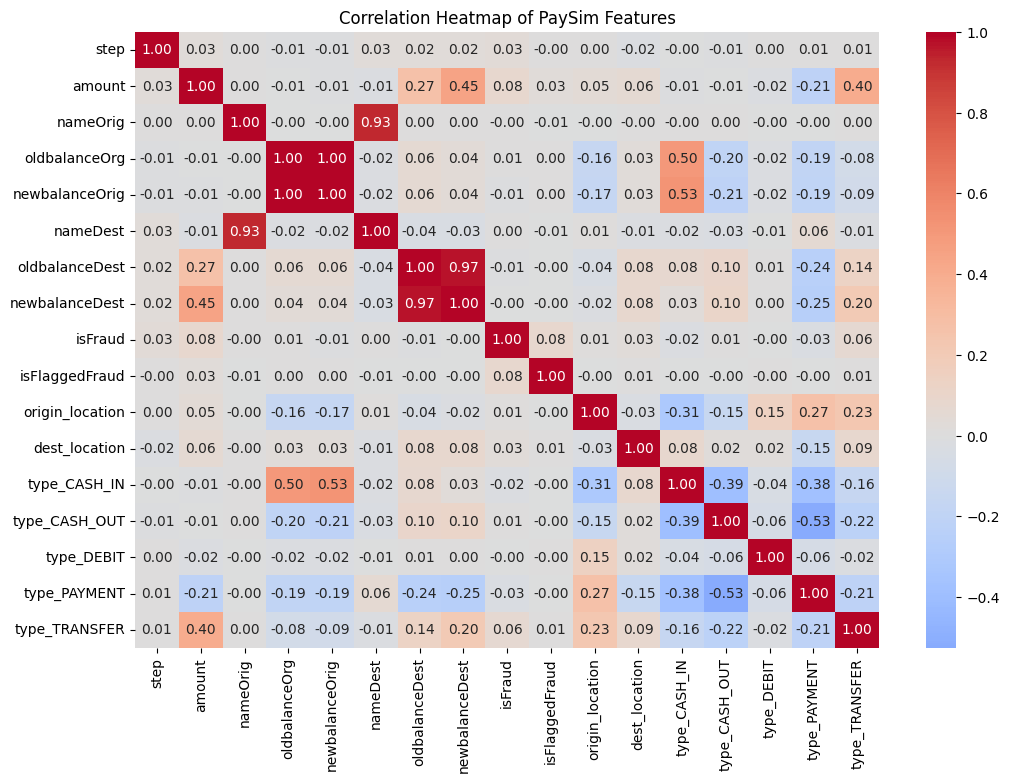

In [ ]:
corr = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlation Heatmap of PaySim Features")
plt.show()

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3737323 to 6142173
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   step             100000 non-null  int64  
 1   amount           100000 non-null  float64
 2   nameOrig         100000 non-null  int64  
 3   oldbalanceOrg    100000 non-null  float64
 4   newbalanceOrig   100000 non-null  float64
 5   nameDest         100000 non-null  int64  
 6   oldbalanceDest   100000 non-null  float64
 7   newbalanceDest   100000 non-null  float64
 8   isFraud          100000 non-null  int64  
 9   isFlaggedFraud   100000 non-null  int64  
 10  origin_location  100000 non-null  int64  
 11  dest_location    100000 non-null  int64  
 12  type_CASH_IN     100000 non-null  float64
 13  type_CASH_OUT    100000 non-null  float64
 14  type_DEBIT       100000 non-null  float64
 15  type_PAYMENT     100000 non-null  float64
 16  type_TRANSFER    100000 non-null  fl

In [ ]:
df_encoded.nunique()

,0
step,463
amount,99573
nameOrig,99999
oldbalanceOrg,54057
newbalanceOrig,43174
nameDest,92914
oldbalanceDest,57742
newbalanceDest,61754
isFraud,2
isFlaggedFraud,2


In [ ]:
df_encoded.describe()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,origin_location,dest_location,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,100000.000000,1.000000e+05,100000.00000,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,243.709070,1.805811e+05,49998.89239,8.366804e+05,8.582234e+05,45309.670180,1.104193e+06,1.230055e+06,0.001410,0.000010,7.468540,6.187400,0.221410,0.35334,0.006120,0.335640,0.083490
std,142.518613,5.586699e+05,28867.24484,2.901104e+06,2.936799e+06,26820.330697,3.223011e+06,3.475326e+06,0.037524,0.003162,4.678541,4.392593,0.415198,0.47801,0.077991,0.472216,0.276623
min,1.000000,9.200000e-01,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,156.000000,1.350821e+04,24999.75000,0.000000e+00,0.000000e+00,21942.750000,0.000000e+00,0.000000e+00,0.000000,0.000000,4.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,240.000000,7.603086e+04,49998.50000,1.393850e+04,0.000000e+00,44729.500000,1.387482e+05,2.185786e+05,0.000000,0.000000,7.000000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,335.000000,2.091130e+05,74998.25000,1.070771e+05,1.464169e+05,68373.250000,9.605963e+05,1.126011e+06,0.000000,0.000000,12.000000,9.000000,0.000000,1.00000,0.000000,1.000000,0.000000
max,736.000000,3.697390e+07,99998.00000,3.359321e+07,3.388709e+07,92913.000000,2.362896e+08,2.724047e+08,1.000000,1.000000,19.000000,19.000000,1.000000,1.00000,1.000000,1.000000,1.000000


ML Model Training

In [ ]:
features = [

    'step',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',

    'type_CASH_OUT',
    'type_DEBIT',
    'type_PAYMENT',
    'type_TRANSFER'
]

X = df_encoded[features]

y = df_encoded['isFraud']

print(X.shape)
print(y.shape)

(100000, 10)
(100000,)


Split Dataset


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (80000, 10)
Testing Data Shape: (20000, 10)


Handle Imbalanced Data using SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
X_train.isnull().sum()

,0
step,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
type_CASH_OUT,0
type_DEBIT,0
type_PAYMENT,0
type_TRANSFER,0


In [ ]:
df_encoded.isna().sum()

,0
step,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
isFlaggedFraud,0


In [ ]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Resample training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: isFraud
0    79887
1      113
Name: count, dtype: int64
After SMOTE: isFraud
0    79887
1    79887
Name: count, dtype: int64


Train Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train_smote, y_train_smote)

print("Model Training Completed")

Model Training Completed


In [ ]:
# Predict using test data

predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


Model Evalution

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, predictions))

# Confusion Matrix
print(confusion_matrix(y_test, predictions))

Accuracy: 0.9906
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     19972
           1       0.11      0.82      0.20        28

    accuracy                           0.99     20000
   macro avg       0.56      0.91      0.60     20000
weighted avg       1.00      0.99      0.99     20000

[[19789   183]
 [    5    23]]


In [ ]:
import joblib
from google.colab import files

# Save model
joblib.dump(model, "fraud_model.pkl")
joblib.dump(features,"feature_columns.pkl")

# Download model
files.download("fraud_model.pkl")
files.download("feature_columns.pkl")

print("Model Saved Successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Saved Successfully


In [ ]:
# Load model

loaded_model = joblib.load("fraud_model.pkl")

# Test prediction
sample_prediction = loaded_model.predict(X_test.iloc[:5])

print(sample_prediction)

[0 0 0 0 0]
